<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sample Size: 250
Mean Tip: 2.7690587934081927
Median Tip: 0.7553316913699188
Zero Tips: 100 out of 250


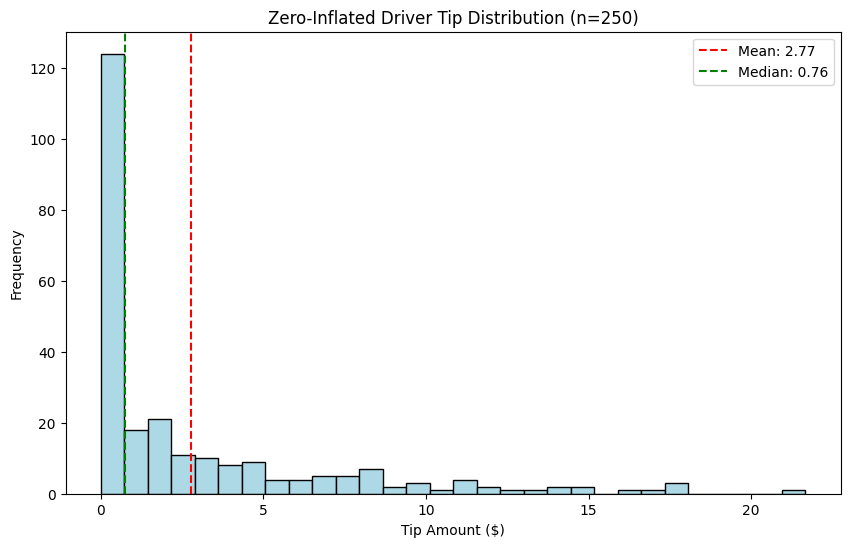

In [63]:
# Phase 1: Bootstrapping Non-Parametric Uncertainty
# Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print("Sample Size:", len(driver_tips))
print("Mean Tip:", np.mean(driver_tips))
print("Median Tip:", np.median(driver_tips))
print("Zero Tips:", np.sum(driver_tips == 0), "out of", len(driver_tips))

# Plot the distribution
plt.figure(figsize=(10,6))
plt.hist(driver_tips, bins=30, edgecolor='k', color='lightblue')
plt.axvline(np.mean(driver_tips), color='red', linestyle='--', label=f'Mean: {np.mean(driver_tips):.2f}')
plt.axvline(np.median(driver_tips), color='green', linestyle='--', label=f'Median: {np.median(driver_tips):.2f}')
plt.title("Zero-Inflated Driver Tip Distribution (n=250)")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Observed Median: 0.7553316913699188
95% CI: [0.265, 1.364]


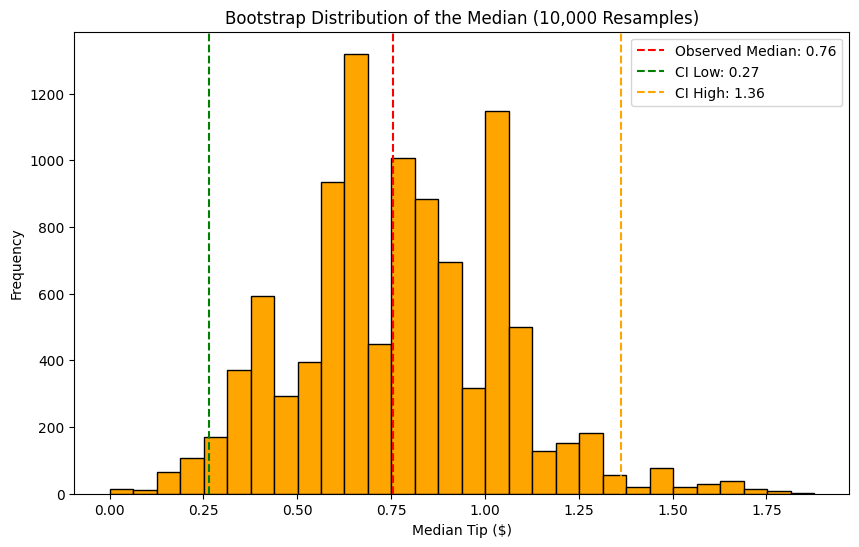

In [64]:
# Step 1.2: The Manual Bootstrap Engine

boot_medians = []

for i in range(10000):
    resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    boot_medians.append(np.median(resample))

boot_medians = np.array(boot_medians)

# Extract the 95% CI using percentiles
ci_low  = np.percentile(boot_medians, 2.5)
ci_high = np.percentile(boot_medians, 97.5)

print("Observed Median:", np.median(driver_tips))
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")

# Plot the bootstrap distribution
plt.figure(figsize=(10,6))
plt.hist(boot_medians, bins=30, edgecolor='k', color='orange')
plt.axvline(np.median(driver_tips), color='red', linestyle='--', label=f'Observed Median: {np.median(driver_tips):.2f}')
plt.axvline(ci_low,  color='green', linestyle='--', label=f'CI Low: {ci_low:.2f}')
plt.axvline(ci_high, color='orange', linestyle='--', label=f'CI High: {ci_high:.2f}')
plt.title("Bootstrap Distribution of the Median (10,000 Resamples)")
plt.xlabel("Median Tip ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# The CI is asymmetric because the data is zero-inflated and right-skewed.
# A parametric t-interval would force symmetry which is wrong for this data.
# Bootstrapping captures the real shape without any distributional assumptions.

Control Mean: 35.03418997294323
Treatment Mean: 32.76920784231749
Observed Difference (Control - Treatment): 2.2649821306257394


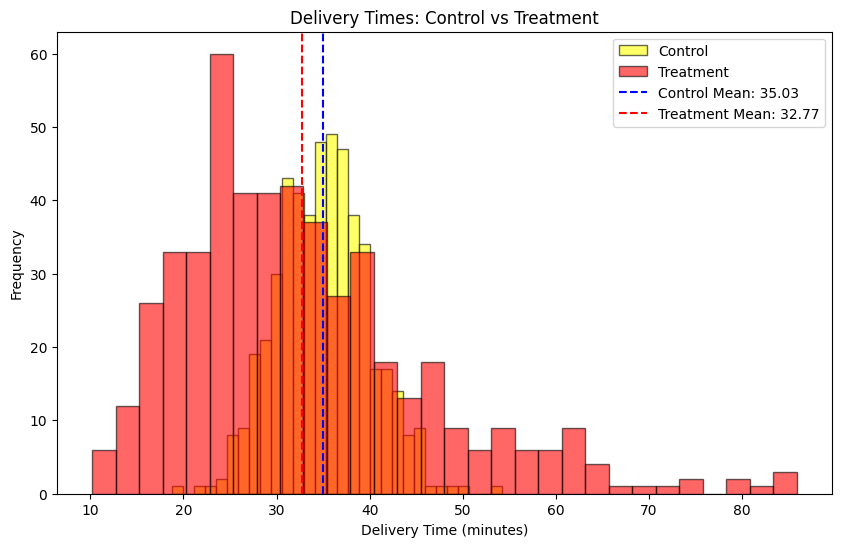

In [65]:
# Phase 2: Falsification in Logistics A/B Testing
# Step 2.1: The Algorithmic Routing Crash

np.random.seed(42)

# Generate the A/B test data
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

# Observed difference in means
obs_diff = control.mean() - treatment.mean()
print("Control Mean:", control.mean())
print("Treatment Mean:", treatment.mean())
print("Observed Difference (Control - Treatment):", obs_diff)

# Plot both distributions
plt.figure(figsize=(10,6))
plt.hist(control, bins=30, alpha=0.6, edgecolor='k', color='yellow', label='Control')
plt.hist(treatment, bins=30, alpha=0.6, edgecolor='k', color='red', label='Treatment')
plt.axvline(control.mean(), color='blue', linestyle='--', label=f'Control Mean: {control.mean():.2f}')
plt.axvline(treatment.mean(), color='red', linestyle='--', label=f'Treatment Mean: {treatment.mean():.2f}')
plt.title("Delivery Times: Control vs Treatment")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Observed Difference: 2.2649821306257394
Permutation P-Value: 0.0004
Reject H0: The algorithm has a significant effect.


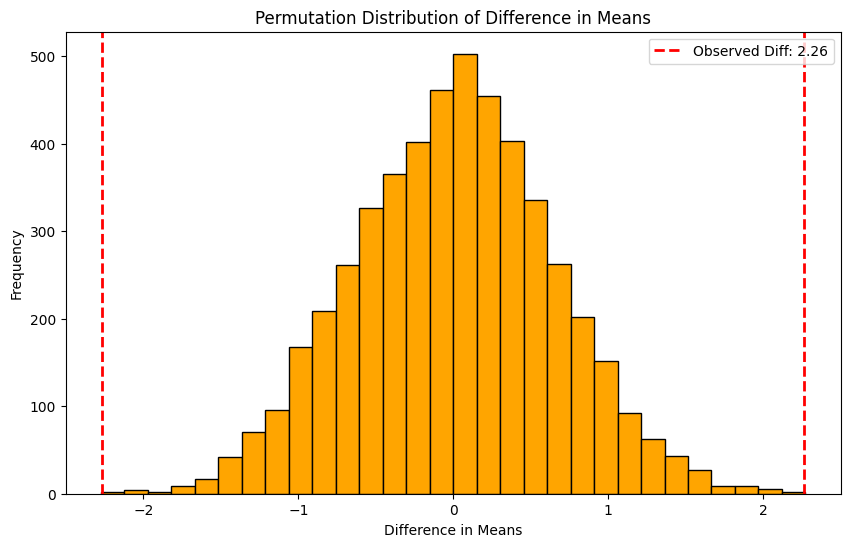

In [66]:
# Step 2.2: The Exact Non-Parametric Permutation Test

# Combine all 1000 deliveries into one pool
all_times = np.concatenate([control, treatment])

# Run 5000 permutations manually
perm_diffs = []

for i in range(5000):
    shuffled = np.random.permutation(all_times)
    fake_control = shuffled[:500]
    fake_treat = shuffled[500:]
    diff = fake_control.mean() - fake_treat.mean()
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

# Calculate empirical p-value
p_val = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
print("Observed Difference:", obs_diff)
print("Permutation P-Value:", p_val)

if p_val < 0.05:
    print("Reject H0: The algorithm has a significant effect.")
else:
    print("Fail to Reject H0: No significant difference detected.")

# Plot the permutation distribution
plt.figure(figsize=(10,6))
plt.hist(perm_diffs, bins=30, edgecolor='k', color='orange')
plt.axvline(obs_diff, color='red', linestyle='--', linewidth=2, label=f'Observed Diff: {obs_diff:.2f}')
plt.axvline(-obs_diff, color='red', linestyle='--', linewidth=2)
plt.title("Permutation Distribution of Difference in Means")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# The treatment group has extreme outliers from crash loops which breaks the homoscedasticity assumption of a t-test.
# The permutation test makes zero assumptions about the distribution, making it the honest choice here.

In [74]:
# Phase 3: Causal Control and the Mitigation of Selection Bias


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Step 3.1: The Loyalty Program Paradox

df = pd.read_csv('swiftcart_loyalty.csv')
print(df.head())
print(df.shape)

# Split into subscribers and non-subscribers
subscribers = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber'] == 0]['post_spend']

# Naive Simple Difference in Means (SDO)
sdo = subscribers.mean() - non_subscribers.mean()
print("Subscriber Mean Spend:", subscribers.mean())
print("Non-Subscriber Mean Spend:", non_subscribers.mean())
print("Naive SDO:", sdo)

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227
(8941, 5)
Subscriber Mean Spend: 74.04358604052543
Non-Subscriber Mean Spend: 56.47291665600164
Naive SDO: 17.57066938452379


   subscriber  propensity_score
0           1          0.546500
1           1          0.548460
2           1          0.683988
3           1          0.779637
4           1          0.397513
5           1          0.536750
6           1          0.827361
7           1          0.777491
8           1          0.294364
9           0          0.446673
Treated Mean Spend: 74.04358604052543
Matched Control Mean Spend: 64.12973085770057
ATT (Causal Estimate): 9.913855182824861
Naive SDO (Biased): 17.57066938452379


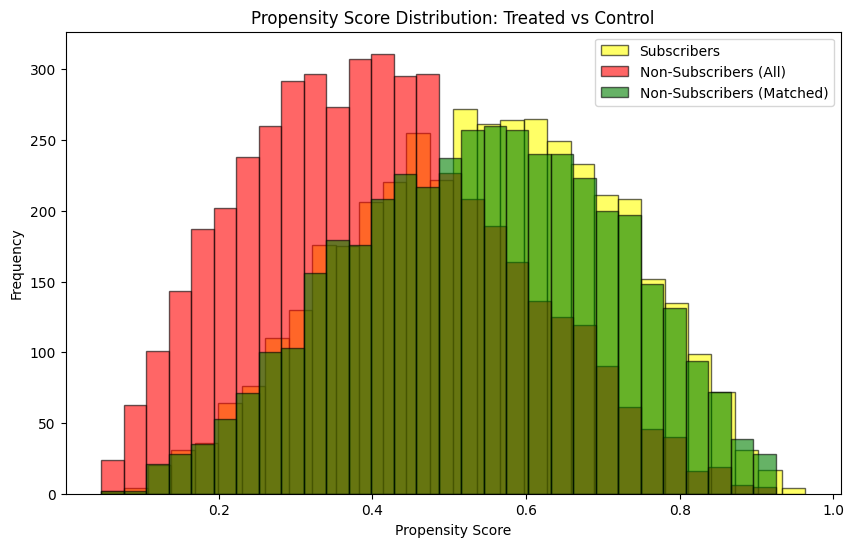

In [68]:
# Step 3.2: Propensity Score Matching (PSM) Architecture

# 1. Define pre-treatment covariates
covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

# 2. Fit logistic regression to get propensity scores
model = LogisticRegression(max_iter=1000)
model.fit(X, D)

df['propensity_score'] = model.predict_proba(X)[:, 1]
print(df[['subscriber', 'propensity_score']].head(10))

# 3. Split treated and control groups
treated  = df[df['subscriber'] == 1].reset_index(drop=True)
controls = df[df['subscriber'] == 0].reset_index(drop=True)

# 4. Match each subscriber to the closest non-subscriber by propensity score
nn = NearestNeighbors(n_neighbors=1)
nn.fit(controls[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_controls = controls.iloc[indices.flatten()].reset_index(drop=True)

# 5. Calculate the ATT (Average Treatment Effect on the Treated)
att = treated['post_spend'].mean() - matched_controls['post_spend'].mean()
print("Treated Mean Spend:", treated['post_spend'].mean())
print("Matched Control Mean Spend:", matched_controls['post_spend'].mean())
print("ATT (Causal Estimate):", att)
print("Naive SDO (Biased):", sdo)

# Plot propensity score distributions before and after matching
plt.figure(figsize=(10,6))
plt.hist(treated['propensity_score'],       bins=30, alpha=0.6, edgecolor='k', color='yellow', label='Subscribers')
plt.hist(controls['propensity_score'],      bins=30, alpha=0.6, edgecolor='k', color='red',       label='Non-Subscribers (All)')
plt.hist(matched_controls['propensity_score'], bins=30, alpha=0.6, edgecolor='k', color='green',  label='Non-Subscribers (Matched)')
plt.title("Propensity Score Distribution: Treated vs Control")
plt.xlabel("Propensity Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# The naive SDO is inflated because high-volume power users self-select into SwiftPass.
# PSM controls for pre-treatment behavior, account age, and support tickets.
# The ATT is the honest causal estimate, stripping out the selection bias.
# Marketing's 300% claim collapses once we compare apples to apples.

In [69]:
# Phase 4: AI Expansion - Task 4.1: The "Love Plot" Visualization

# First, build df_unmatched and df_matched from our Phase 3 work
df_unmatched = df.copy()
df_matched = pd.concat([treated, matched_controls], ignore_index=True)

covariates = ['pre_spend', 'account_age', 'support_tickets']

# Calculate Standardized Mean Differences (SMD) before and after matching
def calc_smd(df, covariates):
    treated_group = df[df['subscriber'] == 1]
    control_group = df[df['subscriber'] == 0]
    smd_list = []
    for col in covariates:
        mean_t = treated_group[col].mean()
        mean_c = control_group[col].mean()
        std_t = treated_group[col].std()
        std_c = control_group[col].std()
        pooled_std = np.sqrt((std_t**2 + std_c**2) / 2)
        smd = (mean_t - mean_c) / pooled_std
        smd_list.append(smd)
    return smd_list

smd_before = calc_smd(df_unmatched, covariates)
smd_after = calc_smd(df_matched, covariates)

print("SMD Before Matching:", smd_before)
print("SMD After Matching: ", smd_after)

# Build a summary dataframe for plotting
smd_df = pd.DataFrame({
    'Covariate': covariates,
    'Before': smd_before,
    'After': smd_after
})
print(smd_df)

SMD Before Matching: [np.float64(0.6739587591272391), np.float64(0.3241093442654683), np.float64(-0.16614617124531833)]
SMD After Matching:  [np.float64(0.013663826310366507), np.float64(-0.015871307844275657), np.float64(0.0171120183892376)]
         Covariate    Before     After
0        pre_spend  0.673959  0.013664
1      account_age  0.324109 -0.015871
2  support_tickets -0.166146  0.017112


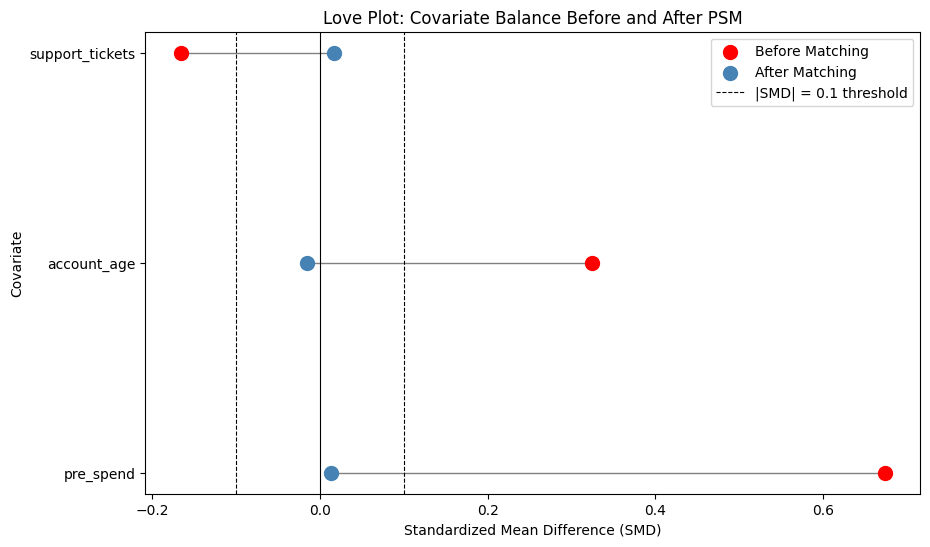

In [70]:
# The Love Plot
plt.figure(figsize=(10,6))
plt.scatter(smd_df['Before'], smd_df['Covariate'], color='red',      s=100, label='Before Matching', zorder=3)
plt.scatter(smd_df['After'],  smd_df['Covariate'], color='steelblue', s=100, label='After Matching',  zorder=3)

# Connect before/after with a line for each covariate
for i, row in smd_df.iterrows():
    plt.plot([row['Before'], row['After']], [row['Covariate'], row['Covariate']], color='grey', linewidth=1)

plt.axvline(0, color='black', linestyle='-',  linewidth=0.8)
plt.axvline(0.1, color='black', linestyle='--', linewidth=0.8, label='|SMD| = 0.1 threshold')
plt.axvline(-0.1, color='black', linestyle='--', linewidth=0.8)

plt.title("Love Plot: Covariate Balance Before and After PSM")
plt.xlabel("Standardized Mean Difference (SMD)")
plt.ylabel("Covariate")
plt.legend()
plt.show()

# Theoretical evaluation:
# A Love Plot proves successful bias mitigation when all SMDs after matching fall within the |0.1| threshold (the vertical dashed lines).
# Before matching, red dots far from 0 reveal selection bias subscribers had higher pre_spend and longer account age by nature.
# After matching, blue dots collapse toward 0, showing the matched control group is now statistically comparable to the treated group on all covariates.
# This is the visual proof that we are comparing apples to apples.